
Processing dataset: HAM
✓ Plot saved to: class_distribution_plots/ham_class_distribution.png


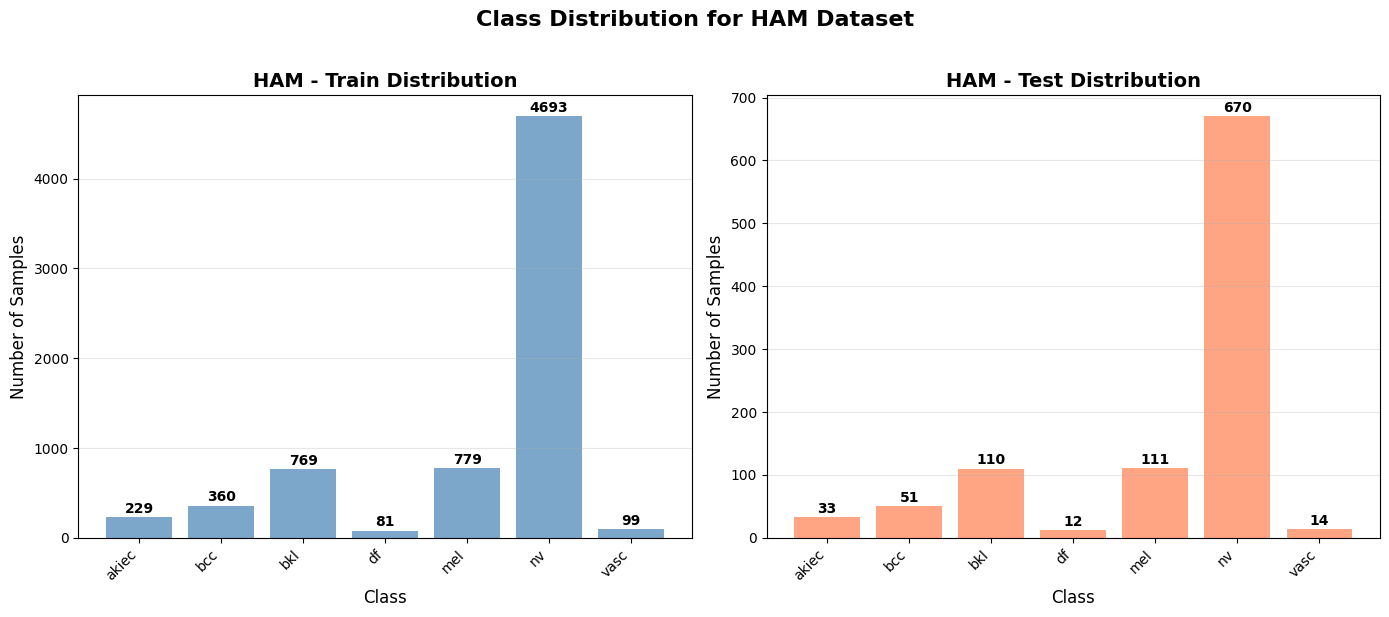


📊 HAM Summary:
  Classes: 7
  Train samples: 7010 (Min: 81, Max: 4693)
  Test samples: 1001 (Min: 12, Max: 670)

Processing dataset: ATLAS_ISIC
✓ Plot saved to: class_distribution_plots/atlas_isic_class_distribution.png


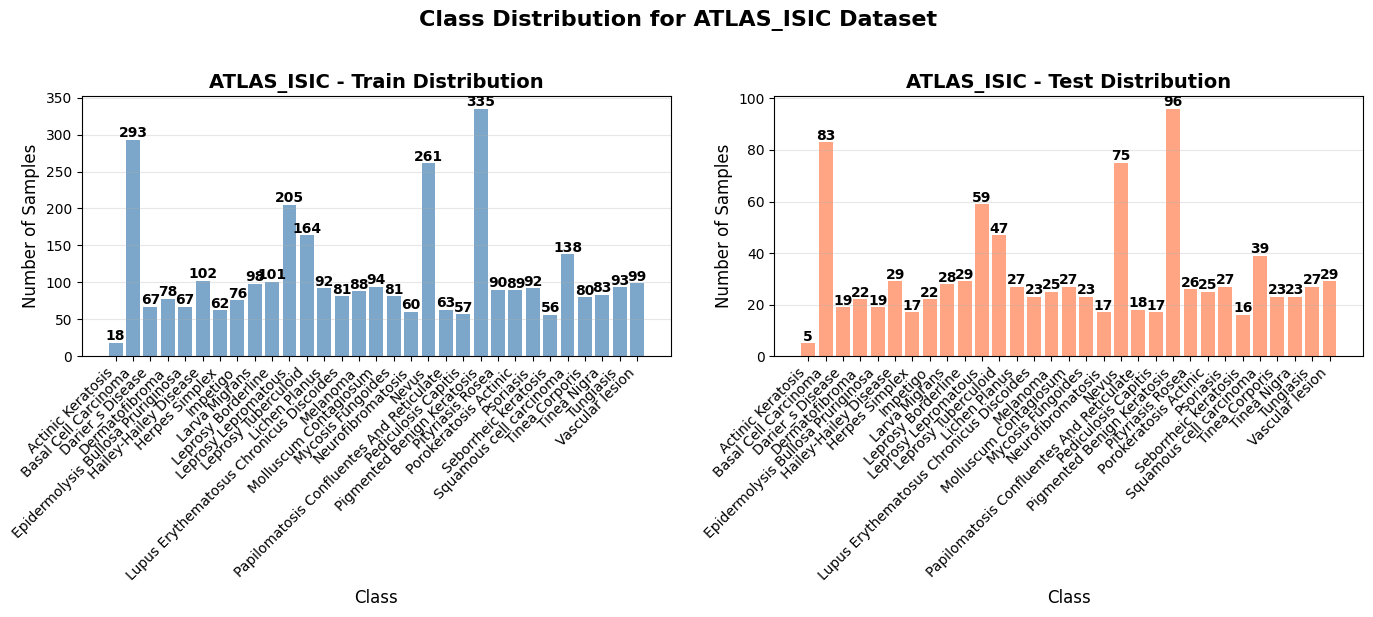


📊 ATLAS_ISIC Summary:
  Classes: 31
  Train samples: 3363 (Min: 18, Max: 335)
  Test samples: 962 (Min: 5, Max: 96)


In [1]:
import os
import matplotlib.pyplot as plt

# Define the dataset dictionary
dataset_dict = {
    "ham": "/data/team01/ds340w/datasets/ham10000_split",
    "atlas_isic": "/data/team01/ds340w/datasets/Atlas_ISIC_split"
}

# Create output directory for plots
output_dir = "class_distribution_plots"
os.makedirs(output_dir, exist_ok=True)

# Loop through each dataset
for dataset_name, dataset_path in dataset_dict.items():
    print(f"\n{'='*60}")
    print(f"Processing dataset: {dataset_name.upper()}")
    print(f"{'='*60}")
    
    # Define train and test directories
    train_dir = os.path.join(dataset_path, "train")
    test_dir = os.path.join(dataset_path, "test")
    
    # Check if directories exist
    if not os.path.exists(train_dir) or not os.path.exists(test_dir):
        print(f"Warning: Directory structure not found for {dataset_name}")
        continue
    
    # Get class folders
    train_class_folders = sorted([f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))])
    test_class_folders = sorted([f for f in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, f))])
    
    # Count samples
    train_counts = [len([f for f in os.listdir(os.path.join(train_dir, folder)) if os.path.isfile(os.path.join(train_dir, folder, f))]) 
                    for folder in train_class_folders]
    test_counts = [len([f for f in os.listdir(os.path.join(test_dir, folder)) if os.path.isfile(os.path.join(test_dir, folder, f))]) 
                   for folder in test_class_folders]
    
    # Create bar charts
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Train distribution
    bars1 = axes[0].bar(range(len(train_class_folders)), train_counts, color='steelblue', alpha=0.7)
    axes[0].set_title(f"{dataset_name.upper()} - Train Distribution", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Class", fontsize=12)
    axes[0].set_ylabel("Number of Samples", fontsize=12)
    axes[0].set_xticks(range(len(train_class_folders)))
    axes[0].set_xticklabels(train_class_folders, rotation=45, ha='right')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, (bar, v) in enumerate(zip(bars1, train_counts)):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(train_counts)*0.01, 
                    str(v), ha='center', fontsize=10, fontweight='bold')
    
    # Test distribution
    bars2 = axes[1].bar(range(len(test_class_folders)), test_counts, color='coral', alpha=0.7)
    axes[1].set_title(f"{dataset_name.upper()} - Test Distribution", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Class", fontsize=12)
    axes[1].set_ylabel("Number of Samples", fontsize=12)
    axes[1].set_xticks(range(len(test_class_folders)))
    axes[1].set_xticklabels(test_class_folders, rotation=45, ha='right')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, (bar, v) in enumerate(zip(bars2, test_counts)):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(test_counts)*0.01, 
                    str(v), ha='center', fontsize=10, fontweight='bold')
    
    plt.suptitle(f"Class Distribution for {dataset_name.upper()} Dataset", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save the plot
    save_path = os.path.join(output_dir, f"{dataset_name}_class_distribution.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved to: {save_path}")
    
    plt.show()
    
    # Print summary
    print(f"\n📊 {dataset_name.upper()} Summary:")
    print(f"  Classes: {len(train_class_folders)}")
    print(f"  Train samples: {sum(train_counts)} (Min: {min(train_counts)}, Max: {max(train_counts)})")
    print(f"  Test samples: {sum(test_counts)} (Min: {min(test_counts)}, Max: {max(test_counts)})")


Creating blurred collage for HAM10000...


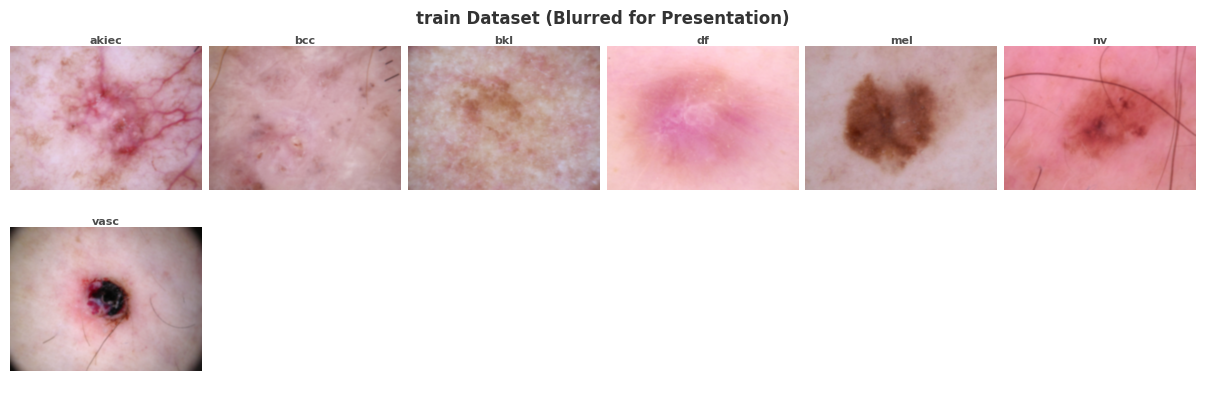


Creating blurred collage for ATLAS_ISIC...


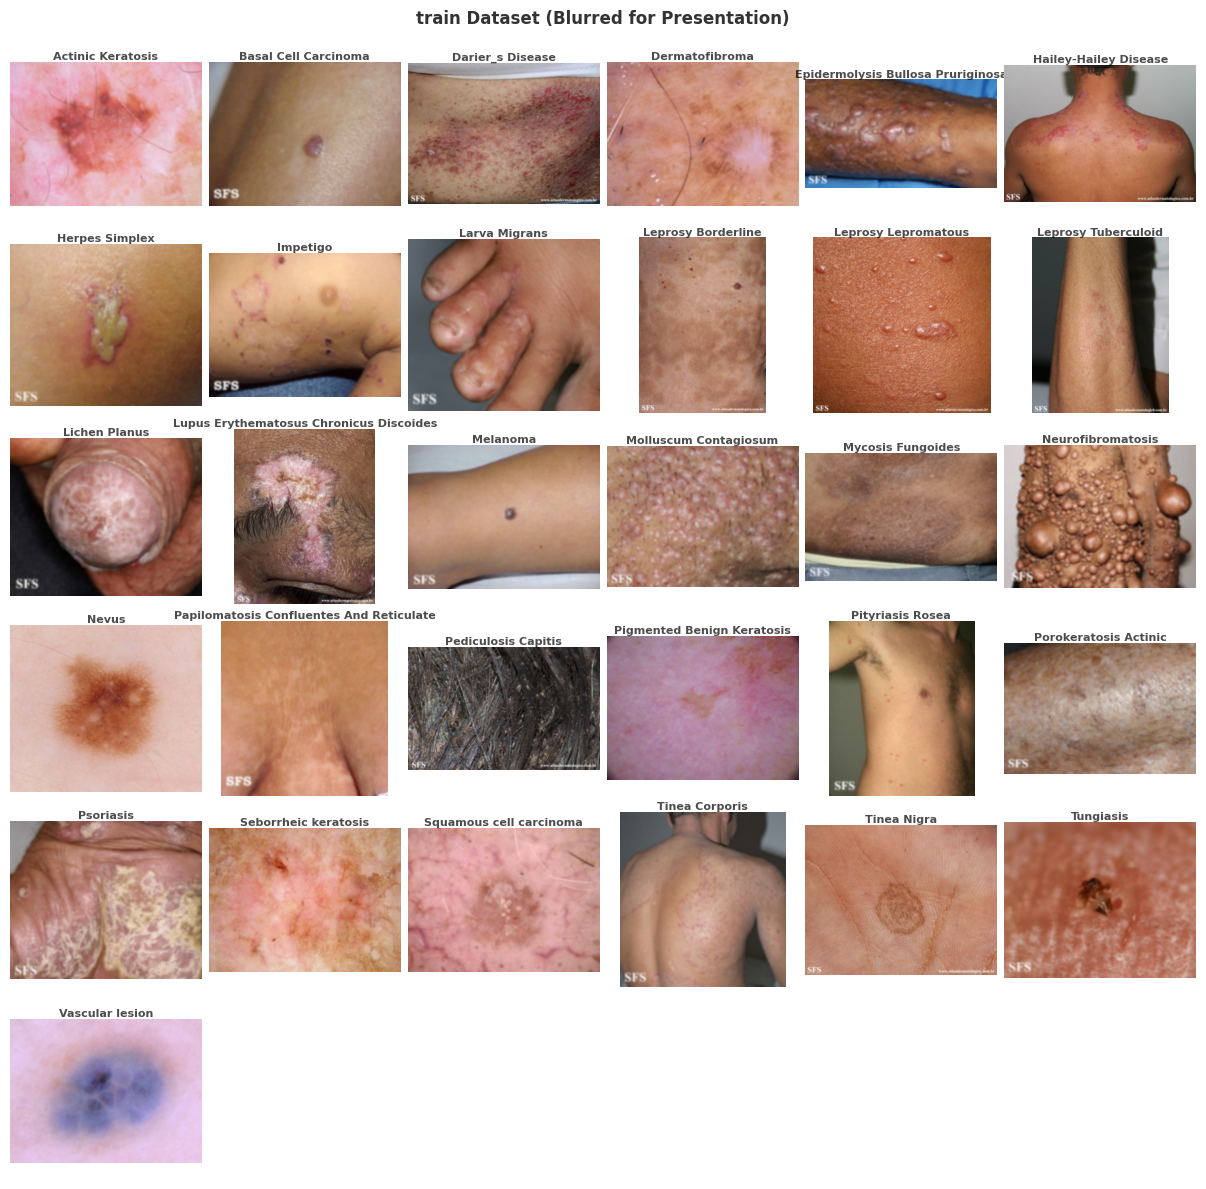


Creating 20% blurred collage for HAM10000...


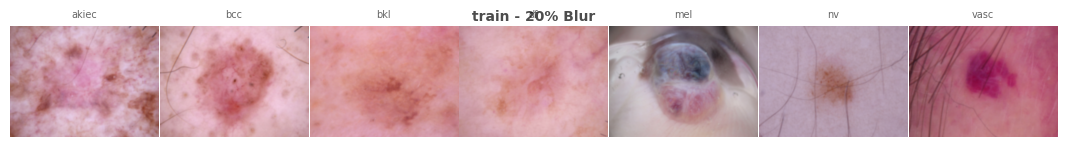


Creating 20% blurred collage for ATLAS_ISIC...


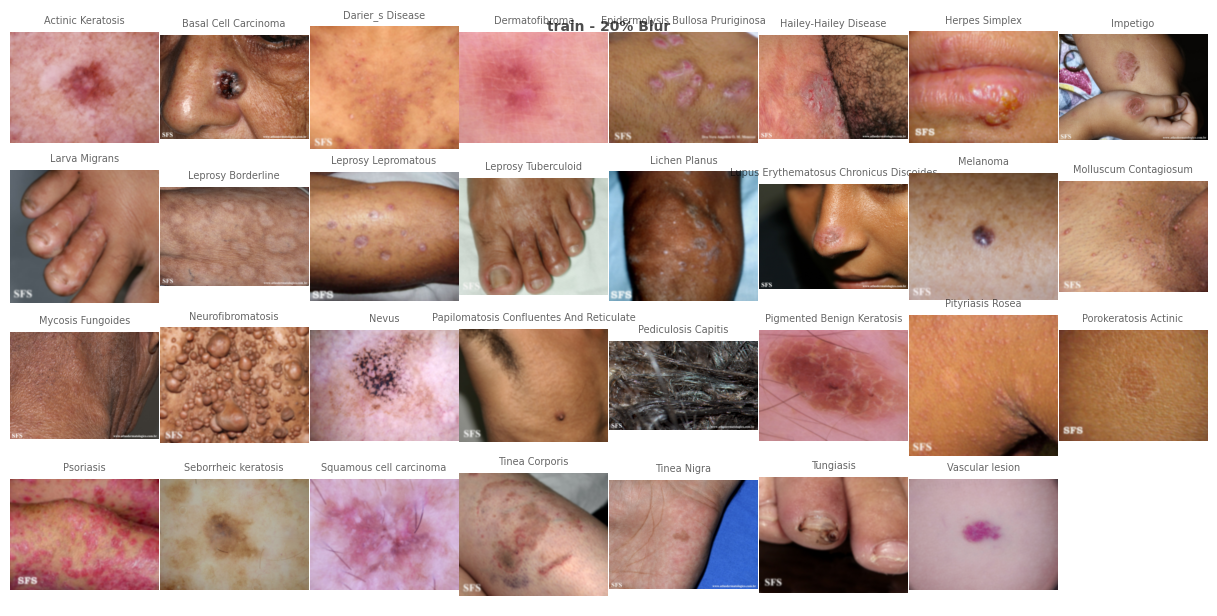

In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import random
import numpy as np

def create_blurred_collage(dataset_path, blur_radius=2, images_per_row=6, img_size=(2, 2)):
    """
    Create a compact grid collage with blurred sample images
    
    Args:
        dataset_path: Path to dataset with class folders
        blur_radius: Radius for Gaussian blur (higher = more blur)
        images_per_row: Number of images per row
        img_size: Size of each subplot in inches
    """
    # Get class folders
    class_folders = sorted([f for f in os.listdir(dataset_path) 
                           if os.path.isdir(os.path.join(dataset_path, f))])
    
    # Collect one image per class
    sample_images = []
    class_names = []
    
    for class_name in class_folders:
        class_path = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if image_files:
            img_path = os.path.join(class_path, random.choice(image_files))
            sample_images.append(img_path)
            class_names.append(class_name)
    
    # Calculate grid dimensions
    n_images = len(sample_images)
    n_cols = min(images_per_row, n_images)
    n_rows = (n_images + n_cols - 1) // n_cols
    
    # Create compact figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * img_size[0], n_rows * img_size[1]))
    
    # Handle single subplot case
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Display blurred images
    for idx, (img_path, class_name) in enumerate(zip(sample_images, class_names)):
        try:
            # Open and blur image
            img = Image.open(img_path)
            blurred_img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))
            
            axes[idx].imshow(blurred_img)
            axes[idx].set_title(class_name, fontsize=8, fontweight='bold', pad=1, alpha=0.7)
        except:
            axes[idx].text(0.5, 0.5, class_name, ha='center', va='center', fontsize=8)
        
        axes[idx].axis('off')
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
    
    # Hide empty subplots
    for idx in range(len(sample_images), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout(pad=0.5)
    plt.subplots_adjust(top=0.95)
    
    # Add title with blur indication
    fig.suptitle(f"{os.path.basename(dataset_path)} Dataset (Blurred for Presentation)", 
                 fontsize=12, fontweight='bold', y=0.98, alpha=0.8)
    
    plt.show()
    return fig

# Even more compact with different blur levels
def create_varied_blur_collage(dataset_path, blur_percent=20, images_per_row=8, img_size=(1.5, 1.5)):
    """
    Create ultra-compact collage with specified blur percentage
    
    Args:
        blur_percent: Blur percentage (0-100, 20 = 20% blur)
        images_per_row: Number of images per row
        img_size: Size of each subplot
    """
    # Convert percentage to blur radius (20% ≈ radius 2)
    blur_radius = (blur_percent / 100) * 10
    
    class_folders = sorted([f for f in os.listdir(dataset_path) 
                           if os.path.isdir(os.path.join(dataset_path, f))])
    
    # Collect images
    sample_images = []
    class_names = []
    
    for class_name in class_folders:
        class_path = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            img_path = os.path.join(class_path, random.choice(image_files))
            sample_images.append(img_path)
            class_names.append(class_name)
    
    n_images = len(sample_images)
    n_cols = min(images_per_row, n_images)
    n_rows = (n_images + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * img_size[0], n_rows * img_size[1]))
    
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, (img_path, class_name) in enumerate(zip(sample_images, class_names)):
        try:
            img = Image.open(img_path)
            # Apply blur
            blurred_img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))
            axes[idx].imshow(blurred_img)
            # Add subtle class label
            axes[idx].set_title(class_name, fontsize=7, alpha=0.6)
        except:
            axes[idx].text(0.5, 0.5, class_name, ha='center', va='center', fontsize=7)
        
        axes[idx].axis('off')
    
    for idx in range(len(sample_images), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout(pad=0.1)
    fig.suptitle(f"{os.path.basename(dataset_path)} - {blur_percent}% Blur", 
                 fontsize=10, fontweight='bold', alpha=0.7)
    
    plt.show()
    return fig

# Create blurred collages
dataset_dict = {
    "HAM10000": "/data/team01/ds340w/datasets/ham10000_split/train",
    "ATLAS_ISIC": "/data/team01/ds340w/datasets/Atlas_ISIC_split/train"
}

# Option 1: Standard blur (radius 2 = ~20% blur)
for dataset_name, dataset_path in dataset_dict.items():
    print(f"\nCreating blurred collage for {dataset_name}...")
    fig = create_blurred_collage(dataset_path, blur_radius=2, images_per_row=6, img_size=(2, 2))
    fig.savefig(f'{dataset_name}_blurred_collage.png', dpi=300, bbox_inches='tight')

# Option 2: Exactly 20% blur
for dataset_name, dataset_path in dataset_dict.items():
    print(f"\nCreating 20% blurred collage for {dataset_name}...")
    fig = create_varied_blur_collage(dataset_path, blur_percent=20, images_per_row=8, img_size=(1.5, 1.5))
    fig.savefig(f'{dataset_name}_20percent_blur.png', dpi=300, bbox_inches='tight')